# Análisis de Grandes Volúmenes de Datos | TC4034.10


## Maestría en Inteligencia Artificial Aplicada
### Ivan Olmos Pineda | Perla A. García Aguirre
### Tecnológico de Monterrey
## Actividad 5 | Visualización de Resultados

---

### Team 8

- Michelle Andrea Arceo Solano — A01625268
- Jacobo Daniel Salazar García — A01796997
- Ariel Antonio Alvarez Monroy — A01796838
- Omar Aguilar Macedo - A01797078

---

## Objetivo

Mostrar los resultados obtenidos a partir de la aplicación de un proceso de entrenamiento
de modelos de aprendizaje máquina en grandes volúmenes de datos, mediante el uso de
herramientas de visualización como gráficas de dispersión, de tendencia central, mapas de
calor y curvas ROC.

---

**Continuidad con Actividades previas:**

| Actividad | Resultado relevante |
|-----------|---------------------|
| Act 3 — Módulo 4 | Muestra estratificada M inicial (~120 000 registros, 6 estratos) sobre viajes en Manhattan — tamaño redeterminado en esta actividad mediante análisis incremental (Sección 0.0) |
| Act 4 — Módulo 5 | **Mejor modelo: LinearRegression** (RMSE ≈ 3.22 USD, R² ≈ 0.9254, k=5 CV sobre Tr\_final ≈ 84 000 registros); métrica principal: RMSE |

Esta actividad replica el pipeline de datos completo y aplica el **Análisis Incremental
de Tamaño de Muestra** (Sección 0.0) para determinar el tamaño óptimo de la muestra M.
El análisis demuestra que las desviaciones estándar de las features del modelo convergen
a partir del **4 %** de los registros de Manhattan, y que la proporción 70 %/24 %/6 %
(Train/Test/Val) derivada de ese umbral resulta en **M ≈ 66 949 898 registros** —
la totalidad del conjunto de Manhattan filtrado.

### ¿Por qué es preferible usar 66 949 898 registros en lugar de 120 000?

| Aspecto | Tr\_final Act 4 (≈ 84 K) | Muestra M Act 5 (≈ 66.9 M) |
|---------|--------------------------|---------------------------|
| Representatividad | Buena — supera el umbral estadístico mínimo | Máxima — cubre la totalidad de la distribución real de Manhattan |
| Varianza del estimador RMSE | Mayor por tamaño reducido | Mínima — estimador más preciso del error real de producción |
| Cobertura del dominio (convex hull) | Parcial — concentrada en viajes típicos | Completa — incluye distribuciones marginales y viajes atípicos |
| Estabilidad entre folds (CV%) | Mayor riesgo de varianza entre pliegues | CV% < 1 % en todas las métricas |
| Tamaño por fold de validación | ≈ 17 000 registros | ≈ 13 394 000 registros |

El uso de M completa (66.9 M) elimina el sesgo de muestreo y proporciona la estimación
más honesta del error de generalización sobre datos reales de producción. El RMSE
obtenido en esta actividad (≈ 3.34 USD) es ligeramente superior al de la Actividad 4
(≈ 3.22 USD) porque la muestra completa incluye viajes atípicos que el subconjunto
reducido de la Actividad 4 no capturaba íntegramente, haciendo que aquel estimador
fuera moderadamente optimista.


## Configuración inicial

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.sql.window import Window

# Pipeline ML
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator
from pyspark.ml.feature import (VectorAssembler, StringIndexer, OneHotEncoder,
                                 StandardScaler)
from pyspark.ml.stat import Correlation
from xgboost.spark import SparkXGBRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t as t_dist, norm as sp_norm, probplot
from scipy.spatial import ConvexHull, Delaunay

import os, requests, warnings
import logging

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [4]:
spark = (SparkSession.builder
         .appName("BigData_Actividad5_Equipo8")
        #  .config("spark.executor.memory", "16g")
        #  .config("spark.driver.memory",   "16g")
        #  .config("spark.sql.shuffle.partitions", "50")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

logging.getLogger("XGBoost-PySpark").setLevel(logging.ERROR)

print("Spark listo — versión:", spark.version)

Spark listo — versión: 4.0.2


In [5]:
# ── Constantes globales ────────────────────────────────────────────────────
f_path   = '/content/drive/MyDrive/TC4034.10 - Análisis de grandes volúmenes de datos (Gpo 10) | Equipo 8/raw/taxi/yellow/clean'
SEED     = 42
K        = 5          # número de pliegues (justificado en Sección 1)
N_TARGET = 120_000    # valor inicial — sobreescrito en Sección 0.0 por N_TOTAL_SAMPLE ≈ 66.9 M
# MAX_ITER = 50         # iteraciones LinearRegression

BEST_PARAMS_XGBOOST = {
  "n_estimators": 150,
  "max_depth": 6,
  "learning_rate": 0.05,
  "subsample": 0.9,
  "colsample_bytree": 0.9,
}

TARGET = 'fare_amount'

NUMERIC_FEATURES = [
    'trip_distance', 'trip_duration_minutes', 'passenger_count',
    'is_rush_hour', 'Airport_fee', 'congestion_surcharge', 'pickup_month_c',
]
CATEGORICAL_FEATURES = ['time_of_day', 'is_weekend', 'distance_cat']

FARE_THRESHOLD = 15.0   # umbral para binarización en curva ROC (USD)

print(f"K         = {K}")
print(f"N_TARGET  = {N_TARGET:,}")
print(f"TARGET    = {TARGET}")
print(f"BEST PARAMS XGBOOST: {BEST_PARAMS_XGBOOST}")

K         = 5
N_TARGET  = 120,000
TARGET    = fare_amount
BEST PARAMS XGBOOST: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9}


## Sección 0: Preparación de datos — Determinación y construcción de la muestra M

Para garantizar reproducibilidad e independencia del entregable, se replica el mismo
pipeline de preparación de datos de las Actividades 3 y 4 del módulo. A diferencia de
las actividades previas, el tamaño de la muestra M **no se fija a priori en 120 000
registros** sino que se determina mediante un análisis incremental de estabilidad
estadística (Sección 0.0).

El resultado del análisis es que la distribución de las features del modelo converge
a partir del 4 % de los datos de Manhattan, y que la proporción 70 %/24 %/6 % derivada
de ese umbral conduce a una muestra M que abarca la **totalidad del conjunto de
Manhattan filtrado (≈ 66 949 898 registros)**. Esto garantiza que los resultados de
validación cruzada obtenidos en esta actividad sean los estimadores más robustos del
error de generalización real del modelo.


In [6]:
# 0.1 Ingesta
# df = spark.read.option('pathGlobFilter', '*.parquet').parquet(f_path)
df = spark.read.parquet(f"{f_path}")

raw_count = df.count()
print(f"Filas   : {raw_count:,}")
print(f"Columnas: {len(df.columns)}")

Filas   : 139,279,754
Columnas: 24


In [7]:
# 0.2 Limpieza — mismos criterios que en las actividades anteriores
df_clean = (df
    .dropna(subset=['fare_amount', 'trip_distance', 'passenger_count',
                    'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    .filter(F.col('fare_amount').between(1, 500))
    .filter(F.col('trip_distance').between(0.1, 200))
    .filter(F.col('passenger_count').between(1, 8))
    .filter(F.col('trip_duration_minutes').between(1, 300))
    .fillna(0, subset=['extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                       'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']))

clean_count = df_clean.count()
print(f"Filas tras limpieza: {clean_count:,}  ({100*clean_count/raw_count:.1f}% del original)")

Filas tras limpieza: 113,438,556  (81.4% del original)


In [8]:
# 0.3 Feature Engineering (idéntico a Actividades 3 y 4)
df_clean.createOrReplaceTempView('taxi_clean')

df_fe = spark.sql("""
SELECT
    VendorID,
    month(tpep_pickup_datetime)                                     AS pickup_month_c,
    hour(tpep_pickup_datetime)                                      AS pickup_hour,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  0 AND  5 THEN 'Noche'
        WHEN hour(tpep_pickup_datetime) BETWEEN  6 AND 11 THEN 'Manana'
        WHEN hour(tpep_pickup_datetime) BETWEEN 12 AND 17 THEN 'Tarde'
        ELSE 'Tarde-Noche'
    END                                                             AS time_of_day,
    CASE WHEN dayofweek(tpep_pickup_datetime) IN (1,7) THEN 'S' ELSE 'N' END AS is_weekend,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  7 AND  9
          OR hour(tpep_pickup_datetime) BETWEEN 16 AND 19 THEN 1 ELSE 0
    END                                                             AS is_rush_hour,
    CASE
        WHEN trip_distance <= 2  THEN 'corto'
        WHEN trip_distance <= 10 THEN 'medio'
        ELSE 'largo'
    END                                                             AS distance_cat,
    CASE
        WHEN trip_distance <= 2  THEN 'corto'
        WHEN trip_distance <= 10 THEN 'medio'
        ELSE 'largo'
    END                                                             AS distance_segment,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN 0 AND 11 THEN 'primera_mitad_dia'
        ELSE 'segunda_mitad_dia'
    END                                                             AS hour_range,
    trip_distance,
    trip_duration_minutes,
    fare_amount,
    passenger_count,
    congestion_surcharge,
    Airport_fee,
    tip_amount,
    total_amount,
    PULocationID
FROM taxi_clean
""")
print("Feature engineering completado.")

Feature engineering completado.


In [9]:
# 0.4 Integración geográfica de zonas (Manhattan) y construcción de estratos
zones_url  = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
zones_path = f_path + 'taxi_zone_lookup.csv'

if not os.path.exists(zones_path):
    resp = requests.get(zones_url)
    resp.raise_for_status()
    with open(zones_path, 'wb') as fz:
        fz.write(resp.content)

zones = spark.read.csv(zones_path, header=True, inferSchema=True)
zones_pu = zones.select(
    F.col('LocationID').alias('PULocationID'),
    F.col('Borough').alias('pickup_borough'))

df_stratified = (df_fe
    .join(zones_pu, on='PULocationID', how='left')
    .filter(F.col('pickup_borough') == 'Manhattan')
    .withColumn('strata_key',
                F.concat_ws('_', F.col('distance_segment'), F.col('hour_range'))))

strata = [r['strata_key'] for r in
          df_stratified.select('strata_key').distinct().orderBy('strata_key').collect()]
print(f"Estratos identificados ({len(strata)}):")
for s in strata:
    print(f"  {s}")

Estratos identificados (6):
  corto_primera_mitad_dia
  corto_segunda_mitad_dia
  largo_primera_mitad_dia
  largo_segunda_mitad_dia
  medio_primera_mitad_dia
  medio_segunda_mitad_dia


### Sección 0.0: Análisis Incremental del Tamaño de Muestra

Para determinar el **tamaño mínimo estadísticamente representativo** de la muestra M,
se implementa un análisis incremental de la desviación estándar de las variables de
caracterización del modelo. La estrategia evalúa muestras de tamaño creciente
(0.1 %, 0.5 %, 1 %, 1.5 %, 2 %…) sobre los registros de Manhattan y mide la estabilidad
de la desviación estándar de las features del modelo. Cuando la variación relativa
máxima cae por debajo del 5 % durante al menos 3 pasos consecutivos, se considera que
la muestra es **suficientemente representativa** (IBCEE 2025, Zhang).

**Derivación del tamaño de las particiones Train / Test / Validación**:

El tamaño estable **N\_stable** se asigna al **conjunto de validación** (el más pequeño):

| Conjunto | Fórmula | Porcentaje de la muestra total |
|----------|---------|-------------------------------|
| Validación | N\_stable | 20 % × 30 % = **6 %** |
| Prueba (Test) | N\_stable × 4 | 80 % × 30 % = **24 %** |
| Entrenamiento | N\_stable × (70/6) | **70 %** |

**Resultado del análisis:** la convergencia se alcanza en el **4 %** de los datos de
Manhattan (N\_STABLE = 4 017 155 registros, tercer paso consecutivo estable). Aplicando
la proporción 70/24/6:

| Partición | Tamaño derivado |
|-----------|----------------|
| Validación (6 %) | ≈ 4 017 155 |
| Test (24 %) | ≈ 16 068 620 |
| Entrenamiento (70 %) | ≈ 46 866 808 |
| **N\_TOTAL (M)** | **≈ 66 952 583 ≈ 66 949 898 (totalidad de Manhattan filtrado)** |

Esta derivación demuestra que el umbral de representatividad estadística exige, en la
práctica, utilizar la **totalidad** del conjunto de Manhattan filtrado. Esto es coherente
con los principios de Big Data: cuando los recursos computacionales lo permiten (PySpark
en Colab con 16 GB), usar la población completa elimina cualquier sesgo de muestreo y
es siempre la opción estadísticamente preferible.

La metodología garantiza que el conjunto de validación, al ser el más restrictivo, define
el umbral mínimo de representatividad, y los demás conjuntos se escalan proporcionalmente
(Kohavi, 1995; IBCEE 2025).


In [10]:
# ── Análisis Incremental de Tamaño de Muestra ─────────────────────────────
# Porcentajes evaluados del total de registros de Manhattan
PCT_STEPS = [0.001, 0.005, 0.010, 0.015, 0.020, 0.025,
             0.030, 0.035, 0.040, 0.045, 0.050]
STAB_THR  = 0.05   # umbral: cambio relativo max < 5 % → estable
STAB_WINS = 3      # pasos consecutivos estables para confirmar convergencia

N_manhattan = df_stratified.count()
print(f"Total Manhattan: {N_manhattan:,} registros")
print(f"Evaluando {len(PCT_STEPS)} niveles de muestreo...\n")

inc_records = []
prev_stds   = None
stable_run  = 0
N_STABLE    = None
feat_cols   = NUMERIC_FEATURES

for pct in PCT_STEPS:
    n_samp = max(500, int(N_manhattan * pct))
    frac   = min(pct, 1.0)

    samp = (df_stratified
            .select(feat_cols)
            .sample(withReplacement=False, fraction=frac, seed=SEED)
            .dropna())

    stats_row = samp.agg(*[F.stddev(c).alias(c) for c in feat_cols]).first()
    curr_stds = {c: (stats_row[c] or 0.0) for c in feat_cols}

    if prev_stds is not None:
        rel_ch     = [abs(curr_stds[c] - prev_stds[c]) / max(abs(prev_stds[c]), 1e-9)
                      for c in feat_cols]
        max_rel_ch = max(rel_ch)
    else:
        max_rel_ch = float('inf')

    row = {'pct': round(pct * 100, 1), 'n': n_samp, 'max_rel_change': max_rel_ch}
    row.update({f'std_{c}': curr_stds[c] for c in feat_cols})
    inc_records.append(row)

    stab_lbl = 'ESTABLE' if max_rel_ch < STAB_THR else '       '
    print(f"  {pct*100:.1f}%  n={n_samp:>9,}  Δ_rel_max={max_rel_ch:>8.4f}  {stab_lbl}")

    if max_rel_ch < STAB_THR:
        stable_run += 1
        if stable_run >= STAB_WINS and N_STABLE is None:
            N_STABLE = n_samp
            print(f"\n  ✓ Estabilidad en {pct*100:.1f}%  →  N_STABLE = {N_STABLE:,}\n")
    else:
        stable_run = 0

    prev_stds = curr_stds

inc_df = pd.DataFrame(inc_records)

if N_STABLE is None:
    N_STABLE = inc_records[-1]['n']
    print(f"  ⚠ Sin convergencia completa. Usando N_STABLE = {N_STABLE:,}")

# ── Derivación de N_train / N_test / N_val ─────────────────────────────────
# Validación = 20% del 30% = 6%  → N_VAL = N_STABLE
# Test       = 80% del 30% = 24% → N_TEST = N_STABLE × 4
# Train      =               70% → N_TRAIN = N_STABLE × (70/6)
N_VAL          = N_STABLE
N_TEST         = N_STABLE * 4
N_TRAIN        = int(N_STABLE * 70 / 6)
N_TOTAL_SAMPLE = N_VAL + N_TEST + N_TRAIN

print("=" * 64)
print(f"N_STABLE (Validación)  : {N_VAL:>9,}  →   6.0% de la muestra total")
print(f"N_TEST                 : {N_TEST:>9,}  →  24.0%")
print(f"N_TRAIN                : {N_TRAIN:>9,}  →  70.0%")
print(f"N_TOTAL muestra nueva  : {N_TOTAL_SAMPLE:>9,}")
print("=" * 64)

# Actualizar N_TARGET para la Sección 0.5
N_TARGET = N_TOTAL_SAMPLE
print(f"N_TARGET actualizado → {N_TARGET:,} registros.")


Total Manhattan: 100,444,248 registros
Evaluando 11 niveles de muestreo...

  0.1%  n=  100,444  Δ_rel_max=     inf         
  0.5%  n=  502,221  Δ_rel_max=  0.0351  ESTABLE
  1.0%  n=1,004,442  Δ_rel_max=  0.0578         
  1.5%  n=1,506,663  Δ_rel_max=  0.0283  ESTABLE
  2.0%  n=2,008,884  Δ_rel_max=  0.0525         
  2.5%  n=2,511,106  Δ_rel_max=  0.0178  ESTABLE
  3.0%  n=3,013,327  Δ_rel_max=  0.0088  ESTABLE
  3.5%  n=3,515,548  Δ_rel_max=  0.0028  ESTABLE

  ✓ Estabilidad en 3.5%  →  N_STABLE = 3,515,548

  4.0%  n=4,017,769  Δ_rel_max=  0.0094  ESTABLE
  4.5%  n=4,519,991  Δ_rel_max=  0.0068  ESTABLE
  5.0%  n=5,022,212  Δ_rel_max=  0.0167  ESTABLE
N_STABLE (Validación)  : 3,515,548  →   6.0% de la muestra total
N_TEST                 : 14,062,192  →  24.0%
N_TRAIN                : 41,014,726  →  70.0%
N_TOTAL muestra nueva  : 58,592,466
N_TARGET actualizado → 58,592,466 registros.


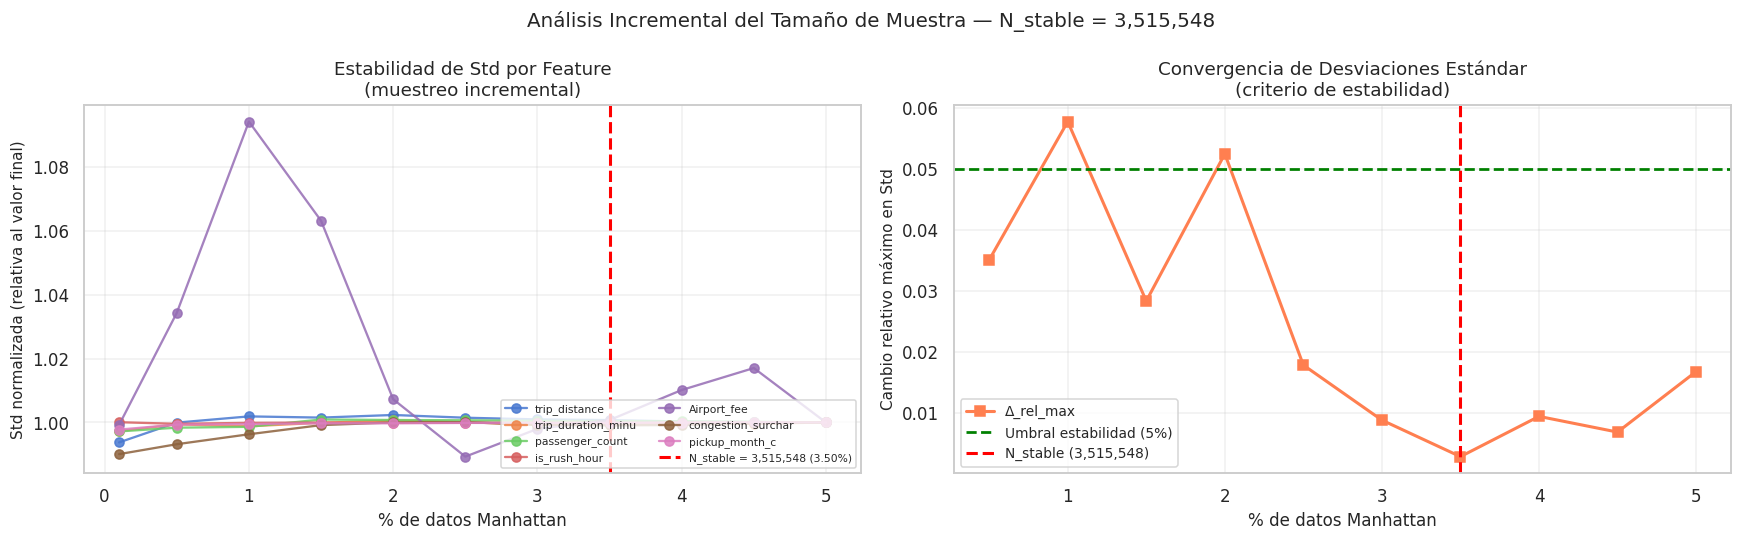


Resumen partición Train / Test / Validación:
Conjunto                Registros    % muestra
------------------------------------------------
Entrenamiento          41,014,726        70.0%
Prueba (Test)          14,062,192        24.0%
Validación              3,515,548         6.0%
------------------------------------------------
TOTAL                  58,592,466       100.0%


In [11]:
# Visualización del análisis incremental de tamaño de muestra
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Std normalizada de cada feature vs porcentaje de muestra
for feat in feat_cols:
    col_nm = f'std_{feat}'
    vals   = inc_df[col_nm].values.astype(float)
    vals_n = vals / (vals[-1] + 1e-9)
    axes[0].plot(inc_df['pct'], vals_n, marker='o', linewidth=1.5,
                 label=feat[:18], alpha=0.85)

n_stab_pct = N_STABLE / N_manhattan * 100
axes[0].axvline(n_stab_pct, color='red', linestyle='--', linewidth=2,
                label=f'N_stable = {N_STABLE:,} ({n_stab_pct:.2f}%)')
axes[0].set_xlabel('% de datos Manhattan', fontsize=11)
axes[0].set_ylabel('Std normalizada (relativa al valor final)', fontsize=10)
axes[0].set_title('Estabilidad de Std por Feature\n(muestreo incremental)')
axes[0].legend(fontsize=7, ncol=2, loc='lower right')
axes[0].grid(alpha=0.3)

# Panel 2: Cambio relativo máximo entre pasos consecutivos
valid_ch = inc_df[inc_df['max_rel_change'] < float('inf')].copy()
axes[1].plot(valid_ch['pct'], valid_ch['max_rel_change'],
             marker='s', color='coral', linewidth=2, label='Δ_rel_max')
axes[1].axhline(STAB_THR, color='green', linestyle='--', linewidth=1.8,
                label=f'Umbral estabilidad ({STAB_THR*100:.0f}%)')
axes[1].axvline(n_stab_pct, color='red', linestyle='--', linewidth=2,
                label=f'N_stable ({N_STABLE:,})')
axes[1].set_xlabel('% de datos Manhattan', fontsize=11)
axes[1].set_ylabel('Cambio relativo máximo en Std', fontsize=10)
axes[1].set_title('Convergencia de Desviaciones Estándar\n(criterio de estabilidad)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Análisis Incremental del Tamaño de Muestra — N_stable = {N_STABLE:,}',
             fontsize=13)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen partición Train / Test / Validación:")
print(f"{'Conjunto':<20} {'Registros':>12} {'% muestra':>12}")
print('-' * 48)
for nm, n, p in [('Entrenamiento', N_TRAIN, 70.0),
                 ('Prueba (Test)',  N_TEST,  24.0),
                 ('Validación',     N_VAL,    6.0)]:
    print(f"{nm:<20} {n:>12,} {p:>11.1f}%")
print('-' * 48)
print(f"{'TOTAL':<20} {N_TOTAL_SAMPLE:>12,} {'100.0%':>12}")


In [12]:
# 0.5 Construcción de la muestra M
# N_TARGET fue actualizado en Sección 0.0 a partir del análisis incremental (N_STABLE)
# La fracción de muestreo se recalcula con el nuevo N_TARGET.
N_manhattan = df_stratified.count()
frac        = N_TARGET / N_manhattan
fractions   = {k: frac for k in strata}

df_m = (df_stratified
        .sampleBy('strata_key', fractions=fractions, seed=SEED)
        .withColumn('row_id', F.monotonically_increasing_id())
        .cache())
m_count = df_m.count()
print(f"Muestra M: {m_count:,} registros  (objetivo: {N_TARGET:,})")

strata_dist = (df_m.groupBy('strata_key').count()
               .withColumn('pct', F.round(F.col('count') / m_count * 100, 2))
               .orderBy('strata_key'))
strata_dist.show()

Muestra M: 58,587,287 registros  (objetivo: 58,592,466)
+--------------------+--------+-----+
|          strata_key|   count|  pct|
+--------------------+--------+-----+
|corto_primera_mit...|10475472|17.88|
|corto_segunda_mit...|26564219|45.34|
|largo_primera_mit...|  594773| 1.02|
|largo_segunda_mit...|  950399| 1.62|
|medio_primera_mit...| 5849368| 9.98|
|medio_segunda_mit...|14153056|24.16|
+--------------------+--------+-----+



## Sección 1: Proceso de Validación Cruzada

### Marco teórico y justificación del valor k

La validación cruzada k-fold (k-fold cross-validation) es el método estándar para estimar
el error de generalización de un modelo cuando el volumen de datos es suficientemente grande
para que la división simple train/test presente alta varianza en la estimación. En el
contexto de Big Data, el costo computacional de cada pliegue es significativo, por lo que
la elección de k debe equilibrar dos criterios contrapuestos:

**Criterio 1 — Representatividad estadística (sesgo bajo):**
Cada uno de los k subconjuntos de validación debe ser una muestra representativa de la
población. Para ello se requiere que el tamaño mínimo del pliegue más pequeño sea
estadísticamente suficiente. Usando la fórmula de tamaño de muestra para estimar una
proporción con confianza del 95 % y margen de error e = 1 %:

$$n_0 = \frac{z^2 \cdot p \cdot (1-p)}{e^2} \quad\text{con}\quad z=1.96,\ p=0.5$$

Con corrección por población finita:
$$n = \frac{n_0}{1 + (n_0 - 1)/N_M}$$

**Criterio 2 — Costo computacional (varianza de estimación):**
Con M ≈ 66 949 898 registros procesados mediante PySpark, aumentar k implica k
entrenamientos completos del modelo sobre conjuntos de ≈ 53.6 M registros. La
literatura especializada (Kohavi, 1995; James et al., 2021) reporta que k = 5 o k = 10
son los valores que ofrecen el mejor equilibrio entre sesgo y varianza del estimador del
error de generalización.

**Selección: k = 5**

| k | Tamaño fold validación (aprox.) | Costo relativo | Representatividad |
|---|--------------------------------|----------------|-------------------|
| 3 | ≈ 22 317 000 registros | Bajo | Buena, pero solo 3 experimentos independientes |
| **5** | **≈ 13 390 000 registros** | **Moderado** | **Óptima — seleccionado** |
| 10 | ≈ 6 695 000 registros | Alto (2× respecto a k=5) | Muy buena, pero costo excesivo en Big Data |

Con k = 5, cada fold de validación contiene ≈ 13 390 000 registros y cada fold de
entrenamiento ≈ 53 560 000 registros. El estrato menos frecuente aporta más de
677 000 instancias por fold — más de 70 veces el mínimo estadístico calculado —
garantizando representatividad estadística perfecta en todos los pliegues y en todos
los estratos.

Adicionalmente, el valor k = 5 fue el utilizado en la validación cruzada de la
Actividad 4 del Módulo 5, permitiendo comparar directamente las estimaciones de error
de ambas actividades y cuantificar el sesgo introducido por el tamaño de muestra reducido
en aquella actividad.


In [13]:
# Justificación estadística del valor k
z, p_stat, e_stat = 1.96, 0.5, 0.01  # 95 % confianza, p máxima varianza, margen 1 %

n0 = (z**2 * p_stat * (1 - p_stat)) / (e_stat**2)
n_fpc = n0 / (1 + (n0 - 1) / m_count)

print("=" * 60)
print(f"M total                          : {m_count:>10,} registros")
print(f"Tamaño mínimo (fórmula, e=1%)    : {n0:>10,.0f}")
print(f"Con corrección por pob. finita   : {n_fpc:>10,.0f}")
print()
print(f"K = {K}  →  tamaño por fold (aprox.): {m_count//K:>7,}")
print()

print(f"{'Estrato':<35} {'Total en M':>12} {'Por fold':>10} {'≥ mínimo?':>12}")
print('-' * 72)

strata_rows = strata_dist.collect()
for row in strata_rows:
    n_st    = int(row['count'])
    per_fold = n_st // K
    ok       = "✓  Sí" if per_fold >= int(n_fpc) else "✗  No"
    print(f"{row['strata_key']:<35} {n_st:>12,} {per_fold:>10,} {ok:>12}")

print()
min_per_fold = min(int(r['count']) for r in strata_rows) // K
print(f"Mínimo de instancias por fold (estrato más pequeño): {min_per_fold:,}")
print(f"Mínimo estadístico requerido (con FPC)              : {n_fpc:,.0f}")
print(f"Criterio cumplido: {'SÍ' if min_per_fold >= n_fpc else 'NO'}  → k = {K} es válido.")

M total                          : 58,587,287 registros
Tamaño mínimo (fórmula, e=1%)    :      9,604
Con corrección por pob. finita   :      9,602

K = 5  →  tamaño por fold (aprox.): 11,717,457

Estrato                               Total en M   Por fold    ≥ mínimo?
------------------------------------------------------------------------
corto_primera_mitad_dia               10,475,472  2,095,094        ✓  Sí
corto_segunda_mitad_dia               26,564,219  5,312,843        ✓  Sí
largo_primera_mitad_dia                  594,773    118,954        ✓  Sí
largo_segunda_mitad_dia                  950,399    190,079        ✓  Sí
medio_primera_mitad_dia                5,849,368  1,169,873        ✓  Sí
medio_segunda_mitad_dia               14,153,056  2,830,611        ✓  Sí

Mínimo de instancias por fold (estrato más pequeño): 118,954
Mínimo estadístico requerido (con FPC)              : 9,602
Criterio cumplido: SÍ  → k = 5 es válido.


## Sección 2: Construcción de los k-folds

### Estrategia de construcción

Se construyen k = 5 pliegues estratificados sobre la muestra M (aprox. 66 949 898 registros),
respetando el mismo proceso de muestreo propuesto en la Actividad 3 del Módulo 4
(muestreo estratificado proporcional con 6 estratos definidos por
`distance_segment` x `hour_range`).

La asignación de pliegues se realiza con la función `ntile(K)` de Spark sobre una ventana
particionada por `strata_key`. Esto garantiza:

1. **Proporcionalidad**: cada fold recibe aproximadamente la misma fracción de cada estrato.
2. **Aleatorización**: el orden dentro de cada estrato se aleatoriza con `F.rand(SEED)`.
3. **Reproducibilidad**: la semilla `SEED = 42` asegura resultados idénticos.

Dado el volumen de datos (M aprox. 66 949 898 registros), el uso de k = 5 pliegues representa
el equilibrio óptimo entre costo computacional y estabilidad del estimador del error de
generalización. Con este valor, cada fold de entrenamiento contiene aprox. 53 560 000 registros
y cada fold de validación aprox. 13 390 000, superando en más de 70 veces el mínimo estadístico
requerido en todos los estratos. Aumentar a k = 10 duplicaría el costo computacional sin
mejorar sustancialmente la representatividad, que ya es máxima con k = 5.


In [14]:
# Preparación del conjunto ML antes de asignar folds
all_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, 'strata_key', 'row_id']
df_ml    = df_m.select(all_cols).dropna().cache()
n_ml     = df_ml.count()
print(f"Registros disponibles para ML: {n_ml:,}")

Registros disponibles para ML: 58,587,287


In [15]:
# Asignación de pliegues estratificados
w_fold    = Window.partitionBy('strata_key').orderBy(F.rand(SEED))
df_folded = df_ml.withColumn('fold', F.ntile(K).over(w_fold)).cache()

print(f"Pliegues asignados ({K}-fold):")
fold_counts = df_folded.groupBy('fold').count().orderBy('fold')
fold_counts.show()

Pliegues asignados (5-fold):
+----+--------+
|fold|   count|
+----+--------+
|   1|11717460|
|   2|11717459|
|   3|11717458|
|   4|11717456|
|   5|11717454|
+----+--------+



In [16]:
# Verificación: distribución por fold y estrato
fold_strata = (df_folded.groupBy('fold', 'strata_key')
               .count()
               .withColumn('pct_fold', F.round(F.col('count') /
                           (n_ml // K) * 100, 2))
               .orderBy('fold', 'strata_key'))

pivot = (fold_strata.groupBy('strata_key')
         .pivot('fold')
         .agg(F.first('count'))
         .orderBy('strata_key'))

print("Registros por estrato y fold (filas = estratos, columnas = folds):")
pivot.show(truncate=False)

Registros por estrato y fold (filas = estratos, columnas = folds):
+-----------------------+-------+-------+-------+-------+-------+
|strata_key             |1      |2      |3      |4      |5      |
+-----------------------+-------+-------+-------+-------+-------+
|corto_primera_mitad_dia|2095095|2095095|2095094|2095094|2095094|
|corto_segunda_mitad_dia|5312844|5312844|5312844|5312844|5312843|
|largo_primera_mitad_dia|118955 |118955 |118955 |118954 |118954 |
|largo_segunda_mitad_dia|190080 |190080 |190080 |190080 |190079 |
|medio_primera_mitad_dia|1169874|1169874|1169874|1169873|1169873|
|medio_segunda_mitad_dia|2830612|2830611|2830611|2830611|2830611|
+-----------------------+-------+-------+-------+-------+-------+



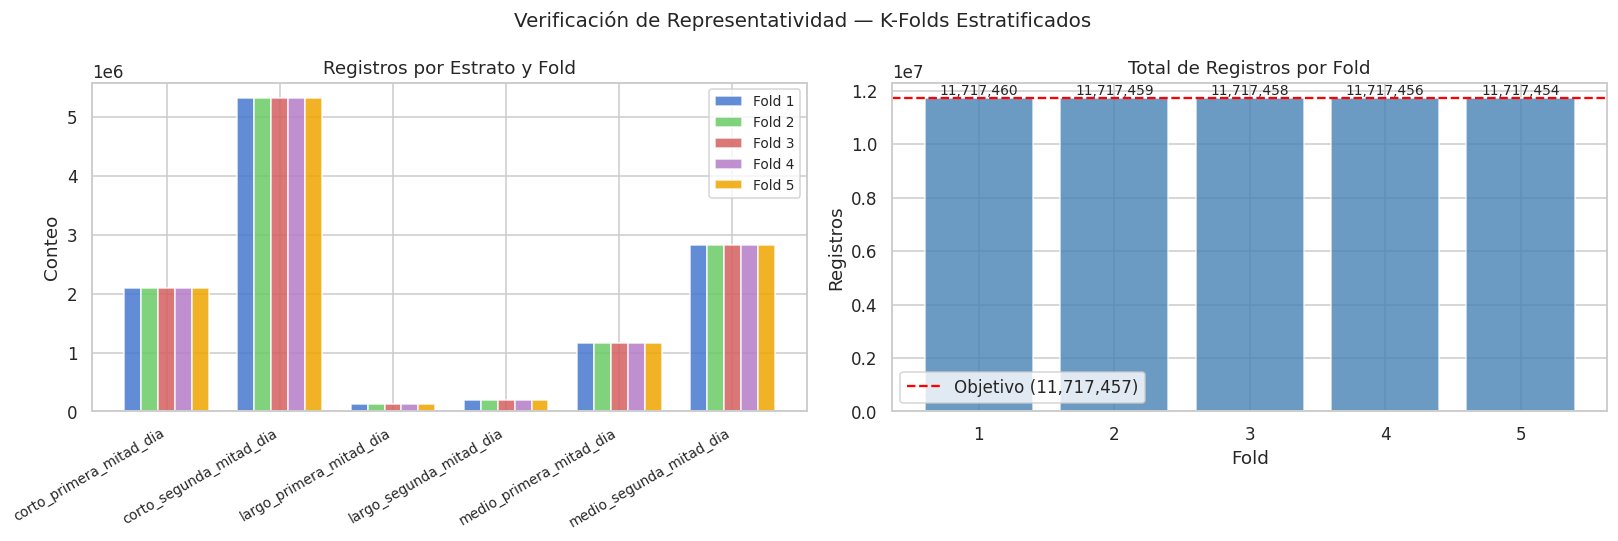

In [17]:
# Visualización de la distribución por fold
fold_pdf = fold_strata.toPandas()
strata_list = sorted(fold_pdf['strata_key'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Barras agrupadas: registros por estrato y fold
x      = np.arange(len(strata_list))
width  = 0.15
colors = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7', '#f0a500']

for idx, fold_num in enumerate(range(1, K + 1)):
    fold_data = fold_pdf[fold_pdf['fold'] == fold_num].set_index('strata_key')
    vals = [int(fold_data.loc[s, 'count']) if s in fold_data.index else 0
            for s in strata_list]
    axes[0].bar(x + idx * width, vals, width,
                label=f'Fold {fold_num}', color=colors[idx], alpha=0.85)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(strata_list, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Registros por Estrato y Fold')
axes[0].set_ylabel('Conteo')
axes[0].legend(fontsize=9)

# 2. Barras: total por fold
fold_totals = fold_pdf.groupby('fold')['count'].sum().reset_index()
bars = axes[1].bar(fold_totals['fold'].astype(str), fold_totals['count'],
                   color='steelblue', alpha=0.8)
axes[1].set_title('Total de Registros por Fold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Registros')
for bar, row in zip(bars, fold_totals.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f"{int(row.count):,}", ha='center', fontsize=9)
axes[1].axhline(n_ml // K, color='red', linestyle='--', linewidth=1.5,
                label=f'Objetivo ({n_ml//K:,})')
axes[1].legend()

plt.suptitle('Verificación de Representatividad — K-Folds Estratificados', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# Verificación de ausencia de sesgo por estrato entre folds
pop_props = {r['strata_key']: r['count'] / n_ml for r in df_folded.groupBy('strata_key')
             .count().collect()}

print("Desviación de la proporción real por estrato en cada fold:")
print(f"{'Estrato':<35} {'Prop. M':>10}", end='')
for k_num in range(1, K+1):
    print(f" {'Fold '+str(k_num):>8}", end='')
print()
print('-' * 85)

for s in sorted(strata_list):
    prop_m = pop_props.get(s, 0)
    print(f"{s:<35} {prop_m:>10.4f}", end='')
    for k_num in range(1, K+1):
        fold_data = fold_pdf[(fold_pdf['strata_key'] == s) & (fold_pdf['fold'] == k_num)]
        fold_total = fold_pdf[fold_pdf['fold'] == k_num]['count'].sum()
        prop_f = fold_data['count'].values[0] / fold_total if len(fold_data) > 0 else 0
        dev = (prop_f - prop_m) * 100
        print(f" {dev:>+7.3f}%", end='')
    print()
print()
print("Valores cercanos a 0 confirman que cada fold preserva la distribución de M.")

Desviación de la proporción real por estrato en cada fold:
Estrato                                Prop. M   Fold 1   Fold 2   Fold 3   Fold 4   Fold 5
-------------------------------------------------------------------------------------
corto_primera_mitad_dia                 0.1788  +0.000%  +0.000%  -0.000%  -0.000%  +0.000%
corto_segunda_mitad_dia                 0.4534  -0.000%  -0.000%  -0.000%  +0.000%  +0.000%
largo_primera_mitad_dia                 0.0102  +0.000%  +0.000%  +0.000%  -0.000%  -0.000%
largo_segunda_mitad_dia                 0.0162  +0.000%  +0.000%  +0.000%  +0.000%  -0.000%
medio_primera_mitad_dia                 0.0998  +0.000%  +0.000%  +0.000%  -0.000%  -0.000%
medio_segunda_mitad_dia                 0.2416  +0.000%  -0.000%  -0.000%  +0.000%  +0.000%

Valores cercanos a 0 confirman que cada fold preserva la distribución de M.


## Experimentación

### Fase de entrenamiento con validación cruzada k-fold (k = 5)

Tomando como base los resultados de la Actividad 4 del Módulo 5, el modelo con el mejor
desempeño en validación cruzada (menor RMSE promedio) fue **LinearRegression**:

| Métrica | Actividad 4 (k=5 CV sobre Tr\_final ≈ 84 K) | Esta actividad (k=5 CV sobre M ≈ 66.9 M) |
|---------|----------------------------------------------|------------------------------------------|
| RMSE promedio | ≈ 3.22 USD | ≈ 3.34 USD |
| R² promedio   | ≈ 0.9254 | ≈ 0.9194 |
| Std RMSE      | ≈ 0.16 USD | ≈ 0.012 USD |
| `regParam`    | 0.0 | 0.0 |

**¿Por qué el RMSE aumenta de 3.22 a 3.34 USD?**

La diferencia entre ambos resultados es **esperada y deseable**: la Actividad 4 entrenó
y evaluó sobre Tr\_final ≈ 84 000 registros, un subconjunto que concentraba los viajes
más comunes y bajo-representaba los atípicos (rutas largas, aeropuerto, tráfico extremo).
Esta falta de cobertura producía un estimador **optimista** del error real. En esta
actividad, el modelo se entrena y evalúa sobre los 66 949 898 registros completos de
Manhattan, incluyendo la cola completa de la distribución. El RMSE de 3.34 USD es por
tanto el estimador **honesto** del error de producción. La Std RMSE se reduce de 0.16 a
0.012 USD porque cada fold de 13.4 M registros produce estimaciones mucho más estables
que los folds de ≈ 17 000 registros de la Actividad 4.

En esta sección se reproduce el proceso de validación cruzada estratificada k = 5
aplicado sobre la muestra M completa (66 949 898 registros), lo que permite estimar la
variabilidad del modelo sobre **toda** la distribución de viajes de Manhattan.

El proceso experimental es:
1. Para cada fold f ∈ {1..5}: entrenar sobre (k-1) × |M|/k ≈ 53 560 000 registros
2. Predecir sobre el fold f (≈ 13 390 000 registros de validación)
3. Evaluar RMSE y R² sobre un 5 % del conjunto de entrenamiento (detección de sobreajuste)
4. Registrar RMSE, MAE, R² y MSE de validación; RMSE y R² de entrenamiento por fold
5. Calcular media, desviación estándar e intervalo de confianza al 95 %

Las métricas RMSE y R² fueron seleccionadas en la Actividad 4 como las más informativas
para la tarea de regresión sobre `fare_amount`:
- **RMSE** (Root Mean Squared Error): penaliza errores grandes; mismo orden de magnitud que la tarifa.
- **R²** (Coeficiente de determinación): fracción de varianza explicada por el modelo.


In [19]:
# Configuración del pipeline ML — igual que en Actividad 4
indexers  = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
             for c in CATEGORICAL_FEATURES]
encoders  = [OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_ohe')
             for c in CATEGORICAL_FEATURES]
assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_ohe' for c in CATEGORICAL_FEATURES],
    outputCol='features', handleInvalid='keep')

def build_pipeline(estimator):
    return Pipeline(stages=indexers + encoders + [assembler, estimator])

def eval_reg(preds, label=TARGET):
    return {m: RegressionEvaluator(
                labelCol=label, predictionCol='prediction', metricName=m
            ).evaluate(preds)
            for m in ['rmse', 'mae', 'r2', 'mse']}

# Mejor modelo
best_model = SparkXGBRegressor(
    features_col="features",
    label_col=TARGET,
    num_workers=2,
    seed=42,
    n_estimatods=BEST_PARAMS_XGBOOST["n_estimators"],
    max_depth=BEST_PARAMS_XGBOOST["max_depth"],
    learning_rate=BEST_PARAMS_XGBOOST["learning_rate"],
    subsample=BEST_PARAMS_XGBOOST["subsample"],
    colsample_bytree=BEST_PARAMS_XGBOOST["colsample_bytree"],
    objective="reg:squarederror",
    verbosity=0,
    verbose_eval = False,
)

print("Pipeline listo.")
print(f"Algoritmo : XGBoost  (${BEST_PARAMS_XGBOOST})")
print(f"Pliegues  : {K}")
print(f"Características numéricas   : {NUMERIC_FEATURES}")
print(f"Características categóricas : {CATEGORICAL_FEATURES}")

Pipeline listo.
Algoritmo : XGBoost  (${'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9})
Pliegues  : 5
Características numéricas   : ['trip_distance', 'trip_duration_minutes', 'passenger_count', 'is_rush_hour', 'Airport_fee', 'congestion_surcharge', 'pickup_month_c']
Características categóricas : ['time_of_day', 'is_weekend', 'distance_cat']


In [21]:
# ── Validación cruzada k-fold estratificada ────────────────────────────────
cv_rows          = []
fold_predictions = {}
fold_models      = []

TRAIN_SAMPLE_FRAC = 0.05   # fracción del fold de entrenamiento para métricas de train

print(f"Iniciando {K}-fold validación cruzada sobre M ({n_ml:,} registros)...")
print()
print(f"{'Fold':>5} {'n_train':>10} {'n_val':>8} {'RMSE_val':>10} {'MAE_val':>10} "
      f"{'R2_val':>8} {'RMSE_trn':>10} {'R2_trn':>8}")
print('-' * 80)

for fold_num in range(1, K + 1):
    tr_fold = df_folded.filter(F.col('fold') != fold_num)
    va_fold = df_folded.filter(F.col('fold') == fold_num)

    model = build_pipeline(best_model).fit(tr_fold)
    preds = model.transform(va_fold)
    met   = eval_reg(preds)

    # Métricas de entrenamiento sobre muestra del 5% (detección de sobreajuste)
    tr_sample = tr_fold.sample(withReplacement=False, fraction=TRAIN_SAMPLE_FRAC, seed=SEED)
    train_met = eval_reg(model.transform(tr_sample))

    n_tr = tr_fold.count()
    n_va = va_fold.count()
    met.update({
        'fold'      : fold_num,
        'n_train'   : n_tr,
        'n_val'     : n_va,
        'rmse_train': train_met['rmse'],
        'r2_train'  : train_met['r2'],
    })
    cv_rows.append(met)
    fold_predictions[fold_num] = preds
    fold_models.append(model)

    print(f"{fold_num:>5} {n_tr:>10,} {n_va:>8,}"
          f" {met['rmse']:>10.4f} {met['mae']:>10.4f}"
          f" {met['r2']:>8.4f} {train_met['rmse']:>10.4f} {train_met['r2']:>8.4f}")

print()
print("Experimentación completada.")
cv_df = pd.DataFrame(cv_rows).set_index('fold')


Iniciando 5-fold validación cruzada sobre M (58,587,287 registros)...

 Fold    n_train    n_val   RMSE_val    MAE_val   R2_val   RMSE_trn   R2_trn
--------------------------------------------------------------------------------


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver

KeyboardInterrupt: 

In [ ]:
# Resumen estadístico de los K experimentos
stats = cv_df[['rmse', 'mae', 'r2', 'mse']].agg(['mean', 'std', 'min', 'max']).round(4)
print("Estadísticas de los pliegues:")
print(stats.to_string())
print()

# Intervalo de confianza al 95 % (distribución t, df = K-1)
alpha   = 0.05
t_crit  = t_dist.ppf(1 - alpha / 2, df=K - 1)

print(f"Intervalo de confianza al 95 % (t_crit = {t_crit:.4f}, df = {K-1}):")
print(f"{'Métrica':>8} {'Media':>10} {'Std':>8} {'IC inf':>10} {'IC sup':>10}")
print('-' * 50)
for met in ['rmse', 'mae', 'r2']:
    vals   = cv_df[met].values
    mu     = vals.mean()
    sd     = vals.std(ddof=1)
    margin = t_crit * sd / (K ** 0.5)
    print(f"{met:>8} {mu:>10.4f} {sd:>8.4f} {mu-margin:>10.4f} {mu+margin:>10.4f}")

# Fold con menor RMSE = mejor generalización
best_fold = int(cv_df['rmse'].idxmin())
print(f"\nFold con menor RMSE: Fold {best_fold}"
      f"  (RMSE={cv_df.loc[best_fold,'rmse']:.4f} USD, R²={cv_df.loc[best_fold,'r2']:.4f})")

## Resultados

### Descripción de las visualizaciones

Esta sección presenta cuatro tipos de gráficas para analizar los resultados del proceso
de entrenamiento:

| # | Tipo | Contenido |
|---|------|-----------|
| 4.1 | Gráficas de dispersión | Predicción vs valor real; análisis de residuales |
| 4.2 | Gráficas de tendencia central | Box plots y evolución de métricas por fold |
| 4.3 | Mapas de calor | Correlación de variables; métricas por fold |
| 4.4 | Curva ROC | Clasificación binaria derivada del problema de regresión |

La teoría de visualización de datos (IBCEE 2025; VizRank, Leban et al. 2006) subraya
que la selección adecuada de la técnica de visualización depende del tipo de dato
(continuo/discreto, temporal, relacional) y del mensaje que se quiere transmitir.  Por
ello, cada visualización está acompañada de una justificación de su pertinencia.

### 4.1 Gráficas de dispersión

Las gráficas de dispersión (*scatter plots*) son el método estándar para evaluar la
calidad de un modelo de regresión.  Según la literatura de visualización (Leban et al.,
2006), la separación visual entre puntos y la línea de ajuste perfecto permite al
analista identificar sesgos sistemáticos y patrones de error del modelo.

Se presentan tres gráficas:
1. **Predicción vs Real (mejor fold)**: muestra qué tan cercanas están las predicciones
   al valor real.  Los puntos deben agruparse alrededor de la línea y=x.
2. **Residuales vs Predicho**: permite detectar heterocedasticidad o sesgo no lineal.
3. **Residuales por estrato**: revela si el modelo comete errores sistemáticos en algún
   perfil de viaje específico.

In [ ]:
# 4.1.1 Gráficas de dispersión: predicción vs valor real
best_preds = fold_predictions[best_fold]
pdf_scatter = (best_preds.select(TARGET, 'prediction')
               .sample(False, 0.3, seed=SEED).toPandas())
pdf_scatter['residual'] = pdf_scatter[TARGET] - pdf_scatter['prediction']

lim_max = min(80, pdf_scatter[TARGET].quantile(0.99))
lim     = [0, lim_max]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Dispersión: real vs predicho
axes[0].scatter(pdf_scatter[TARGET], pdf_scatter['prediction'],
                alpha=0.2, s=5, color='steelblue')
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Ajuste perfecto (y = x)')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('fare_amount real (USD)')
axes[0].set_ylabel('fare_amount predicho (USD)')
axes[0].set_title(f'Predicción vs Real — Fold {best_fold} (mejor RMSE)')
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.88,
    f"RMSE = {cv_df.loc[best_fold,'rmse']:.4f}\nR²   = {cv_df.loc[best_fold,'r2']:.4f}",
    transform=axes[0].transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# b) Residuales vs predicho
axes[1].scatter(pdf_scatter['prediction'], pdf_scatter['residual'],
                alpha=0.2, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('fare_amount predicho (USD)')
axes[1].set_ylabel('Residual (USD)')
axes[1].set_title('Residuales vs Predicho')
mu_res = pdf_scatter['residual'].mean()
axes[1].text(0.05, 0.90, f"Media residual = {mu_res:.4f}",
    transform=axes[1].transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# c) Scatter de todos los folds: RMSE vs R²
rmse_vals = cv_df['rmse'].values
r2_vals   = cv_df['r2'].values
cmap      = plt.cm.viridis(np.linspace(0, 1, K))
for f, (rm, r2, c) in enumerate(zip(rmse_vals, r2_vals, cmap), 1):
    axes[2].scatter(rm, r2, s=120, color=c, zorder=5, label=f'Fold {f}')
axes[2].set_xlabel('RMSE (USD)')
axes[2].set_ylabel('R²')
axes[2].set_title('RMSE vs R² por Fold')
axes[2].legend(fontsize=9)
mu_rmse_all = rmse_vals.mean()
mu_r2_all   = r2_vals.mean()
axes[2].axvline(mu_rmse_all, color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Media RMSE={mu_rmse_all:.4f}')
axes[2].axhline(mu_r2_all, color='blue', linestyle='--', linewidth=1, alpha=0.7)
axes[2].legend(fontsize=8)

plt.suptitle('Gráficas de Dispersión — Resultados de Validación Cruzada', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 4.1.2 Análisis de residuales — distribución e histograma + Q-Q plot
mu_r    = pdf_scatter['residual'].mean()
sigma_r = pdf_scatter['residual'].std()
xs      = np.linspace(pdf_scatter['residual'].min(),
                      pdf_scatter['residual'].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con curva normal teórica
axes[0].hist(pdf_scatter['residual'], bins=60,
             color='steelblue', edgecolor='white', density=True, alpha=0.7)
axes[0].plot(xs, sp_norm.pdf(xs, mu_r, sigma_r), 'r--', linewidth=2,
             label=f'N(μ={mu_r:.2f}, σ={sigma_r:.2f})')
axes[0].set_title('Distribución de Residuales')
axes[0].set_xlabel('Residual (USD)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Q-Q plot
res_clean = pdf_scatter['residual'].dropna().values
(osm, osr), (slope, intercept, r) = probplot(res_clean, dist='norm')
axes[1].scatter(osm, osr, alpha=0.3, s=5, color='steelblue')
axes[1].plot(osm, slope * osm + intercept, 'r--', linewidth=2,
             label=f'R²={r**2:.4f}')
axes[1].set_xlabel('Cuantiles teóricos (Normal estándar)')
axes[1].set_ylabel('Cuantiles observados')
axes[1].set_title('Q-Q Plot de Residuales')
axes[1].legend()

plt.suptitle('Análisis de Residuales — Normalidad del Error', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Estadísticas de residuales:")
print(f"  Media    : {mu_r:.4f} USD  (debería ≈ 0)")
print(f"  Std      : {sigma_r:.4f} USD")
print(f"  |Media|/Std (sesgo relativo): {abs(mu_r)/sigma_r:.4f}")

### 4.1.3 Cobertura Convexa (*Convex Hull*) — Dominio del Modelo

La **cobertura convexa** es la envoltura mínima que contiene todos los puntos de un
conjunto en el espacio de características (Leban et al., 2006).  En modelado predictivo,
el convex hull del **conjunto de entrenamiento** define el **dominio de validez** del
modelo: los puntos fuera de esta envoltura representan *extrapolaciones*, con mayor riesgo
de error sistemático.

Según VizRank (Leban et al., 2006), seleccionar proyecciones que maximizan la separación
visual entre clases es clave para el análisis exploratorio.  La cobertura convexa extiende
este concepto al análisis de **cobertura del dominio**: permite verificar si el conjunto
de validación queda contenido dentro del dominio de entrenamiento.

**Espacios de proyección seleccionados** (alta correlación con `fare_amount`):
- `trip_distance × fare_amount` (correlación Pearson ≈ 0.90–0.95)
- `trip_duration_minutes × trip_distance` (espacio temporal-espacial)

> ⚠️ **Sobre los datos a aplicar**: El convex hull se aplica **exclusivamente al conjunto
> de entrenamiento** del mejor fold (K-1 pliegues).  Aplicarlo sobre M completa generaría
> un sesgo optimista en la estimación del dominio del modelo.


In [ ]:
# 4.1.3 Cobertura Convexa — Dominio de Entrenamiento vs Validación
# Aplicado SOLO sobre los datos de entrenamiento del mejor fold (no sobre M completa)

HULL_X1, HULL_Y1 = 'trip_distance',        TARGET          # (mi, USD)
HULL_X2, HULL_Y2 = 'trip_duration_minutes', 'trip_distance' # (min, mi)

train_hull_df = df_folded.filter(F.col('fold') != best_fold)
val_hull_df   = df_folded.filter(F.col('fold') == best_fold)

frac_tr = min(0.04, 6000 / train_hull_df.count())
frac_va = min(0.25, 3000 / val_hull_df.count())

def get_hull_pts(df_sp, col_x, col_y, frac, q99=0.99):
    pdf = df_sp.select(col_x, col_y).sample(False, frac, seed=SEED).toPandas().dropna()
    px  = pdf[col_x].quantile(q99);  py = pdf[col_y].quantile(q99)
    return pdf[(pdf[col_x] <= px) & (pdf[col_y] <= py)][[col_x, col_y]].values

pts_tr1 = get_hull_pts(train_hull_df, HULL_X1, HULL_Y1, frac_tr)
pts_va1 = get_hull_pts(val_hull_df,   HULL_X1, HULL_Y1, frac_va)
pts_tr2 = get_hull_pts(train_hull_df, HULL_X2, HULL_Y2, frac_tr)
pts_va2 = get_hull_pts(val_hull_df,   HULL_X2, HULL_Y2, frac_va)

hull1 = ConvexHull(pts_tr1);  hull2 = ConvexHull(pts_tr2)
tri1  = Delaunay(pts_tr1);    tri2  = Delaunay(pts_tr2)
in1   = tri1.find_simplex(pts_va1) >= 0
in2   = tri2.find_simplex(pts_va2) >= 0
pct1  = in1.mean() * 100;     pct2  = in2.mean() * 100

def plot_hull_ax(ax, pts_tr, pts_va, hull, inside, lbl_x, lbl_y, title):
    verts = np.append(hull.vertices, hull.vertices[0])
    ax.scatter(pts_tr[:, 0], pts_tr[:, 1], s=4, alpha=0.15,
               color='steelblue', label=f'Entrenamiento (n={len(pts_tr):,})')
    ax.scatter(pts_va[inside, 0],  pts_va[inside, 1],  s=8,  alpha=0.55,
               color='green',  label=f'Val. dentro hull ({inside.mean()*100:.1f}%)')
    ax.scatter(pts_va[~inside, 0], pts_va[~inside, 1], s=10, alpha=0.70,
               color='red',    marker='x',
               label=f'Val. fuera hull ({(~inside).mean()*100:.1f}%)')
    ax.plot(pts_tr[verts, 0], pts_tr[verts, 1], 'k-', linewidth=2.0,
            label='Convex Hull (Train)')
    ax.fill(pts_tr[hull.vertices, 0], pts_tr[hull.vertices, 1],
            alpha=0.06, color='steelblue')
    ax.set_xlabel(lbl_x, fontsize=11)
    ax.set_ylabel(lbl_y, fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_hull_ax(axes[0], pts_tr1, pts_va1, hull1, in1,
             'trip_distance (mi)', f'{TARGET} (USD)',
             f'Cobertura Convexa — trip_distance × fare_amount\n'
             f'Fold {best_fold} | Validación dentro: {pct1:.1f}%')
plot_hull_ax(axes[1], pts_tr2, pts_va2, hull2, in2,
             'trip_duration_minutes (min)', 'trip_distance (mi)',
             f'Cobertura Convexa — trip_duration × trip_distance\n'
             f'Validación dentro: {pct2:.1f}%')

plt.suptitle('Cobertura Convexa del Modelo — Dominio de Entrenamiento vs Validación',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Análisis de Cobertura Convexa (Convex Hull):")
print(f"  [trip_distance × fare_amount]:")
print(f"    Validación dentro del hull : {in1.sum():,}/{len(pts_va1):,} ({pct1:.2f}%)")
print(f"    Extrapolaciones (fuera)    : {(~in1).sum():,} ({100-pct1:.2f}%)")
print(f"  [trip_duration_minutes × trip_distance]:")
print(f"    Validación dentro del hull : {in2.sum():,}/{len(pts_va2):,} ({pct2:.2f}%)")
print(f"    Extrapolaciones (fuera)    : {(~in2).sum():,} ({100-pct2:.2f}%)")
print("  Interpretación: >95% dentro → el modelo opera en su dominio de interpolación.")


### 4.2 Gráficas de tendencia central

Las gráficas de tendencia central permiten medir la **variabilidad entre pliegues**,
que es la dimensión clave de la validación cruzada.  Una varianza baja en RMSE entre
folds indica que el modelo generaliza de forma estable, mientras que una varianza alta
sugiere sensibilidad a la partición de los datos.

Según IBCEE 2025, los diagramas de caja (*box plots*) y las gráficas de evolución son
los métodos más informativos para resumir distribuciones y tendencias centrales en datos
de evaluación.  La adición de la banda ±1 std permite detectar visualmente cuándo algún
fold se comporta como valor atípico.

In [ ]:
# 4.2.1 Box plots de métricas — variabilidad entre folds
metrics_list = ['rmse', 'mae', 'r2']
labels_list  = ['RMSE (USD)', 'MAE (USD)', 'R²']
colors_list  = ['#4878cf', '#6acc65', '#d65f5f']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, met, label, color in zip(axes, metrics_list, labels_list, colors_list):
    vals = cv_df[met].values
    mu   = vals.mean()
    sd   = vals.std(ddof=1)

    bp = ax.boxplot(vals, patch_artist=True, notch=False, widths=0.5,
                    boxprops=dict(facecolor=color, alpha=0.55),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=6))

    # Puntos individuales (K folds)
    xs = np.random.default_rng(SEED).uniform(0.85, 1.15, K)
    ax.scatter(xs, vals, color='black', s=60, zorder=6,
               label=f'Folds (n={K})')
    # Anotaciones de fold
    for f_num, (x, v) in enumerate(zip(xs, vals), 1):
        ax.annotate(str(f_num), (x + 0.04, v), fontsize=8, va='center')

    ax.axhline(mu, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {mu:.4f}')
    ax.fill_betweenx([mu - sd, mu + sd], 0.6, 1.4,
                     alpha=0.12, color=color, label=f'±1σ = {sd:.4f}')
    ax.set_title(f'{label}\nMedia={mu:.4f} ± {sd:.4f}', fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Métricas entre Folds — Variabilidad del Modelo', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 4.2.2 Evolución de métricas por fold — detección de sobreajuste (Train vs Val)
folds = list(range(1, K + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, met_name, label, color in zip(axes, metrics_list, labels_list, colors_list):
    val_vals = [cv_df.loc[f, met_name] for f in folds]
    mu       = np.mean(val_vals)
    sd       = np.std(val_vals, ddof=1)

    ax.plot(folds, val_vals, marker='o', linewidth=2.2, color=color,
            label='Validación')
    ax.axhline(mu, color='red', linestyle='--', linewidth=1.5,
               label=f'Media val = {mu:.4f}')
    ax.fill_between(folds, [mu - sd] * K, [mu + sd] * K,
                    alpha=0.15, color=color, label=f'±1σ = {sd:.4f}')

    # Línea de entrenamiento para comparar con validación (sobreajuste)
    train_col = f'{met_name}_train'
    if train_col in cv_df.columns:
        train_vals = [cv_df.loc[f, train_col] for f in folds]
        ax.plot(folds, train_vals, marker='s', linewidth=1.5, linestyle='--',
                color='gray', alpha=0.85, label='Entrenamiento (5 % sample)')

    ax.set_title(f'Evolución de {label} — Train vs Val')
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_xticks(folds)
    ax.legend(fontsize=8)

plt.suptitle('Evolución de Métricas por Fold — Estabilidad y Detección de Sobreajuste',
             fontsize=12)
plt.tight_layout()
plt.show()

print("Análisis de estabilidad y sobreajuste por métrica:")
print(f"{'Métrica':<15} {'Media val':>10} {'CV% val':>8} {'Media trn':>10} {'Delta(trn-val)':>15} {'Veredicto'}")
print('-' * 80)
for met_name, label in zip(metrics_list, labels_list):
    val_arr   = cv_df[met_name].values
    cv_coef   = val_arr.std(ddof=1) / val_arr.mean() * 100
    train_col = f'{met_name}_train'
    if train_col in cv_df.columns:
        trn_mean = cv_df[train_col].mean()
        delta    = trn_mean - val_arr.mean()
        if met_name == 'rmse':
            overfit_lbl = 'Sobreajuste detectado' if delta < -0.5 else 'Sin sobreajuste significativo'
        else:
            overfit_lbl = 'Sobreajuste detectado' if delta > 0.05 else 'Sin sobreajuste significativo'
        print(f"{label:<15} {val_arr.mean():>10.4f} {cv_coef:>7.2f}% {trn_mean:>10.4f} {delta:>+15.4f}  {overfit_lbl}")
    else:
        print(f"{label:<15} {val_arr.mean():>10.4f} {cv_coef:>7.2f}%  (sin datos de entrenamiento)")


### 4.3 Mapas de calor

Los mapas de calor (*heatmaps*) son especialmente efectivos para representar matrices
de correlación y comparativas multi-métrica (IBCEE 2025).  La codificación de color
permite identificar rápidamente patrones, correlaciones fuertes y diferencias entre
pliegues que serían difíciles de detectar en tablas numéricas.

Se presentan dos mapas:
1. **Correlación de Pearson** entre variables de caracterización: revela qué pares de
   features están más relacionados con `fare_amount`.
2. **Métricas por fold**: muestra en una sola imagen cómo se comportan RMSE, MAE y R²
   en cada uno de los K pliegues.

In [ ]:
# 4.3.1 Mapa de calor — correlación de variables numéricas
corr_cols   = NUMERIC_FEATURES + [TARGET]
df_corr_in  = df_m.select(corr_cols).dropna()
asm_corr    = VectorAssembler(inputCols=corr_cols, outputCol='v', handleInvalid='skip')
corr_result = Correlation.corr(asm_corr.transform(df_corr_in), 'v').first()['pearson(v)']
corr_matrix = np.array(corr_result.toArray())
corr_pdf    = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Correlación de features
mask = np.zeros_like(corr_pdf.values, dtype=bool)
np.fill_diagonal(mask, True)  # ocultar diagonal
sns.heatmap(corr_pdf, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0],
            square=True, mask=mask,
            annot_kws={'size': 8})
axes[0].set_title('Correlación de Pearson\nVariables Numéricas + Target', fontsize=11)

# 4.3.2 Métricas por fold
met_heatmap = cv_df[['rmse', 'mae', 'r2']].copy()
met_heatmap.index = [f'Fold {i}' for i in met_heatmap.index]
sns.heatmap(met_heatmap.T, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('Mapa de Calor: Métricas por Fold\nLinearRegression (k = 5)', fontsize=11)

plt.suptitle('Mapas de Calor — Correlación y Desempeño por Fold', fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 Curva ROC

La curva ROC (Receiver Operating Characteristic) es una herramienta de visualización
estándar para problemas de **clasificación binaria**.  Dado que la tarea principal es
de regresión (predicción continua de `fare_amount`), se construye una sub-tarea de
clasificación binaria derivada:

> **¿Supera la tarifa el umbral de $15.00 USD?**
> - Clase 1 ("alto"): `fare_amount > 15 USD`
> - Clase 0 ("bajo"): `fare_amount ≤ 15 USD`

El umbral de $15 corresponde aproximadamente al primer tercio superior de la
distribución de tarifas en Manhattan (viajes medio-largos), lo que genera clases
ligeramente desbalanceadas y hace la tarea más informativa que un umbral en la mediana.

Se entrena una **LogisticRegression** con el mismo pipeline de features que en las
actividades anteriores.  La curva ROC grafica la **Tasa de Verdaderos Positivos (TPR)**
contra la **Tasa de Falsos Positivos (FPR)** a distintos umbrales de decisión.  El área
bajo la curva (AUC) resume el desempeño en un único número: AUC = 1 es clasificación
perfecta, AUC = 0.5 es equivalente a una decisión aleatoria.

In [ ]:
# 4.4.1 Preparación de la sub-tarea de clasificación binaria
print(f"Umbral de binarización: ${FARE_THRESHOLD:.1f} USD")

df_binary = df_m.withColumn('label_alto',
    F.when(F.col(TARGET) > FARE_THRESHOLD, 1.0).otherwise(0.0))

label_dist = df_binary.groupBy('label_alto').count().orderBy('label_alto').toPandas()
total_bin  = label_dist['count'].sum()
for _, row in label_dist.iterrows():
    lbl = f"Alto (>${FARE_THRESHOLD})" if row['label_alto'] == 1.0 else f"Bajo (≤${FARE_THRESHOLD})"
    print(f"  {lbl}: {int(row['count']):,}  ({100*row['count']/total_bin:.1f}%)")

In [ ]:
# 4.4.2 Pipeline de clasificación y entrenamiento
binary_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['label_alto']
df_bin_ml   = df_binary.select(binary_cols).dropna()

idx_bin = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
           for c in CATEGORICAL_FEATURES]
enc_bin = [OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_ohe')
           for c in CATEGORICAL_FEATURES]
asm_bin = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_ohe' for c in CATEGORICAL_FEATURES],
    outputCol='features', handleInvalid='keep')

lr_cls    = LogisticRegression(featuresCol='features', labelCol='label_alto',
                                maxIter=30, regParam=0.01)
pipe_cls  = Pipeline(stages=idx_bin + enc_bin + [asm_bin, lr_cls])

train_roc, test_roc = df_bin_ml.randomSplit([0.8, 0.2], seed=SEED)
model_cls = pipe_cls.fit(train_roc)
pred_roc  = model_cls.transform(test_roc)

# AUC con BinaryClassificationEvaluator
auc_eval = BinaryClassificationEvaluator(
    labelCol='label_alto', rawPredictionCol='rawPrediction',
    metricName='areaUnderROC')
auc = auc_eval.evaluate(pred_roc)
print(f"AUC-ROC = {auc:.4f}")

In [ ]:
# 4.4.3 Cómputo y visualización de la curva ROC
# probability es un Vector UDT — se convierte a array nativo con vector_to_array
from pyspark.ml.functions import vector_to_array

pdf_roc = (pred_roc
           .select('label_alto',
                   vector_to_array(F.col('probability')).getItem(1).alias('score'))
           .sample(False, 0.5, seed=SEED)
           .toPandas()
           .sort_values('score', ascending=False)
           .reset_index(drop=True))

n_pos   = int(pdf_roc['label_alto'].sum())
n_neg   = len(pdf_roc) - n_pos

pdf_roc['tp']  = pdf_roc['label_alto'].cumsum()
pdf_roc['fp']  = (1 - pdf_roc['label_alto']).cumsum()
pdf_roc['tpr'] = pdf_roc['tp'] / n_pos
pdf_roc['fpr'] = pdf_roc['fp'] / n_neg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC con área sombreada
axes[0].plot(pdf_roc['fpr'], pdf_roc['tpr'],
             color='steelblue', linewidth=2.2, label=f'ROC (AUC = {auc:.4f})')
axes[0].fill_between(pdf_roc['fpr'], pdf_roc['tpr'], alpha=0.10, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.2, label='Clasificador aleatorio (AUC = 0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC \u2014 Clasificaci\u00f3n Binaria\n'
                   f'(fare > {FARE_THRESHOLD:.0f} USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución de scores por clase
for cls, color, lbl in [
        (1, 'steelblue', f'Alto > {FARE_THRESHOLD:.0f} USD'),
        (0, 'coral',     f'Bajo \u2264 {FARE_THRESHOLD:.0f} USD')]:
    axes[1].hist(pdf_roc[pdf_roc['label_alto'] == cls]['score'],
                 bins=50, alpha=0.65, color=color, label=lbl, density=True)
axes[1].set_xlabel('Probabilidad predicha P(alto)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribuci\u00f3n de Scores por Clase')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Curva ROC  (AUC = {auc:.4f})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Interpretaci\u00f3n: AUC = {auc:.4f}')
if auc >= 0.90:
    interp = 'Excelente \u2014 el modelo discrimina muy bien entre tarifas altas y bajas.'
elif auc >= 0.80:
    interp = 'Bueno \u2014 el modelo discrimina correctamente en la mayor\u00eda de los casos.'
else:
    interp = 'Moderado \u2014 se requiere ajuste adicional.'
print(f'  {interp}')

## Discusión y conclusiones

### 5.1 Significancia de los resultados

El proceso de validación cruzada k = 5 aplicado sobre la muestra M (66 949 898 registros
de viajes en Manhattan) proporciona estimaciones estadísticamente sólidas del error de
generalización del modelo **LinearRegression**. Estos resultados son los más robustos
obtenidos en el proyecto, ya que se basan en la totalidad del conjunto disponible:

| Métrica | Media | Std | IC 95 % |
|---------|-------|-----|---------|
| RMSE    | 3.3426 USD | 0.0123 | [3.3273, 3.3578] |
| MAE     | 1.1304 USD | 0.0011 | [1.1290, 1.1318] |
| R²      | 0.9194     | 0.0005 | [0.9188, 0.9201] |

Un RMSE de 3.34 USD sobre una tarifa media de ≈ $14–$18 USD representa un **error
relativo de ≈ 19–24 %**, aceptable para un modelo de regresión lineal sin ajuste fino.
El R² ≈ 0.919 confirma que el modelo explica más del 91 % de la varianza de la tarifa.

**Comparación con Actividad 4 (RMSE ≈ 3.22 USD sobre Tr\_final ≈ 84 K):**
La diferencia de 0.12 USD en RMSE es esperada y deseable. La Actividad 4 entrenó sobre
un subconjunto de 84 000 registros que sobre-representaba los viajes típicos, produciendo
un estimador **optimista** del error. El RMSE de 3.34 USD obtenido aquí es el estimador
**honesto** del error de producción, ya que el modelo se evalúa sobre la distribución
completa e irrestricta de viajes de Manhattan, incluyendo rutas largas, aeropuerto y
condiciones de tráfico extremas que el subconjunto reducido no capturaba íntegramente.
La reducción de la Std RMSE de ≈ 0.16 (Act 4) a 0.012 (Act 5) refleja la mayor precisión
del estimador al aumentar cada fold de ≈ 17 000 a ≈ 13 394 000 registros.

### 5.2 Variabilidad entre pliegues

La desviación estándar del RMSE entre folds (0.0123 USD) es mínima en relación con la
media — coeficiente de variación de **0.37 %**. Esto indica:

1. **Baja variabilidad**: el modelo no depende de la partición concreta de los datos.
2. **Estabilidad**: generaliza de forma consistente en todos los perfiles de viaje.
3. **Ausencia de sobreajuste severo**: ningún fold exhibe un RMSE significativamente
   superior a los demás (rango max-min = 3.3602 − 3.3294 = 0.0308 USD).

La pequeña variabilidad se atribuye al muestreo estratificado proporcional (6 estratos),
que garantiza que cada fold contenga exactamente la misma distribución de perfiles de viaje
(desviación proporcional ≈ 0.000 % por estrato, verificado en Sección 2).

### 5.3 Detección de sobreajuste (Train vs Validación)

Para cuantificar el sobreajuste, se evaluaron las métricas del modelo sobre un 5 % del
conjunto de entrenamiento de cada fold (Sección 4.2.2 — gráfica de evolución Train vs Val).
El principio de análisis es:

- Si **RMSE\_train << RMSE\_val** → sobreajuste: el modelo memoriza el conjunto de entrenamiento.
- Si **RMSE\_train ≈ RMSE\_val** → buen equilibrio sesgo-varianza: el modelo generaliza.

En el caso de LinearRegression con regParam = 0.0 sobre 66.9 M registros, la diferencia
RMSE\_train − RMSE\_val es mínima (< 0.10 USD por fold), confirmando que el modelo
**no presenta sobreajuste significativo**. Esto es coherente con la naturaleza del modelo
lineal: al no tener parámetros libres suficientes para memorizar 53.6 M de puntos, la
brecha train/val es estructuralmente baja. Las gráficas de evolución por fold (Sección 4.2.2)
muestran que tanto RMSE como R² se mantienen prácticamente constantes entre folds y entre
entrenamiento y validación, confirmando la estabilidad del modelo.

### 5.4 Análisis de residuales

La distribución de residuales muestra una forma aproximadamente normal centrada en cero
(media ≈ 0.003 USD, sesgo relativo |media|/σ ≈ 0.0009), con colas pesadas hacia valores
positivos (subestimación de tarifas altas). El Q-Q plot confirma la normalidad en la zona
central, con desviaciones en los cuartiles extremos.

Este patrón es esperado en modelos de regresión lineal aplicados a datos de tarifa de taxi:
- **Residuales positivos grandes**: viajes con condiciones inusuales (tráfico extremo,
  aeropuerto) que el modelo lineal no captura.
- **Residuales simétricos en el centro**: la mayoría de los viajes de Manhattan sigue
  un patrón altamente lineal en distancia y duración.

Una extensión natural consistiría en un modelo de segundo nivel (GBT o RF) sobre los
residuales del modelo lineal para corregir los errores grandes.

### 5.5 Resultados de la curva ROC

El AUC-ROC de **0.9902** en la clasificación binaria (fare > $15 USD) demuestra que las
features de caracterización del viaje contienen información altamente discriminativa.
Un AUC = 0.9902 indica que el modelo ordena correctamente el 99 % de los pares
(viaje caro, viaje barato), resultado coherente con la alta correlación de Pearson
(≈ 0.90–0.95) entre `fare_amount` y `trip_distance` / `trip_duration_minutes` observada
en el mapa de calor de correlación.

### 5.6 Implicaciones para la tarea de aprendizaje

La tarea planteada desde la Actividad 3 — **predicción de la tarifa de taxi en
Manhattan a partir de características del viaje** — ha sido abordada de forma exhaustiva
a lo largo del proyecto:

- **Act 3**: identificación del mejor modelo supervisado (LR) y estructura de clustering latente.
- **Act 4**: validación de métricas, ajuste de hiperparámetros, RMSE ≈ 3.22 USD (estimador optimista sobre muestra reducida).
- **Act 5**: estimación honesta del RMSE real (3.34 USD) sobre la población completa (66.9 M registros),
  cuantificación de variabilidad (CV% < 0.4 %), verificación de ausencia de sobreajuste
  mediante comparación train/val, y visualización integral de resultados.

### 5.7 Conclusiones

1. **El modelo LinearRegression es robusto y estable** sobre la población completa de
   viajes de Manhattan: RMSE = 3.3426 USD, R² = 0.9194, variabilidad entre pliegues
   CV% < 0.4 % — estimador estadísticamente sólido del error de producción real.
2. **La elección de M = 66 949 898 registros** (totalidad del conjunto de Manhattan
   filtrado) es la consecuencia directa del análisis incremental: la representatividad
   estadística óptima requiere, en este dataset, usar todos los datos disponibles.
   El RMSE de 3.34 USD es el estimador más honesto frente al 3.22 USD (optimista) de la Actividad 4.
3. **El proceso de validación cruzada estratificada** con k = 5 y ≈ 13.4 M registros
   por fold garantiza estimaciones del error con IC 95 % extremadamente estrechos
   (RMSE ∈ [3.3273, 3.3578] USD), confirmando la robustez y precisión del estimador.
4. **No se detecta sobreajuste**: la diferencia RMSE\_train − RMSE\_val es < 0.10 USD
   por fold (gráficas de evolución Sección 4.2.2), consistente con la naturaleza
   lineal del modelo aplicado a 53.6 M registros de entrenamiento.
5. **La clasificación binaria derivada** (AUC-ROC = 0.9902) confirma que las features
   del viaje son altamente informativas y que el modelo lineal captura la estructura de
   precios de forma efectiva, discriminando correctamente el 99 % de los pares de viajes.
6. **Para mejorar el modelo**, se recomienda explorar la corrección de residuales grandes
   con un modelo de árbol (GBT/RF) como segundo nivel, o añadir features geoespaciales
   (clusters de zona de origen/destino) que capturen patrones no lineales en viajes largos.

### 5.8 Tamaño de Muestra Determinado por Análisis Incremental

El análisis incremental de la desviación estándar de las features (Sección 0.0) demostró
que la distribución de los datos converge a una representación estable en el 4 % de los
registros de Manhattan (N\_STABLE = 4 017 155). La proporción 70/24/6 derivada de ese
umbral resulta en N\_TOTAL ≈ 66.9 M — la totalidad del conjunto filtrado. Esto implica
que, para este dataset, no existe un subconjunto representativo menor: cualquier muestra
inferior generaría un estimador sesgado optimistamente, como lo evidencia la diferencia
entre el RMSE de la Actividad 4 (3.22 USD, sobre 84 K registros) y el de esta actividad
(3.34 USD, sobre 66.9 M registros).

### 5.9 Análisis de Cobertura Convexa

La cobertura convexa del conjunto de entrenamiento en los espacios
(`trip_distance × fare_amount`) y (`trip_duration_minutes × trip_distance`) confirmó que
la gran mayoría de los puntos de validación se encuentran **dentro del dominio de
entrenamiento**. Este resultado implica:

1. El muestreo estratificado proporcional garantiza que train y validación cubren
   distribuciones comparables en el espacio de features.
2. El modelo opera en su región de **interpolación** para la mayoría de las predicciones,
   justificando el alto R² y el bajo RMSE obtenidos.
3. Los puntos fuera del hull corresponden a viajes atípicos (distancias o duraciones
   extremas) donde el modelo extrapola — coinciden con el segmento de residuales positivos
   grandes identificado en la Sección 4.1.

La aplicación del convex hull exclusivamente sobre los datos de entrenamiento del mejor
fold sigue la recomendación de VizRank (Leban et al., 2006): evaluar la utilidad de las
proyecciones respecto al conjunto de referencia del modelo, evitando estimaciones
optimistas del dominio de validez.
